Tạo 2 cột Order Hour Range (cách nhau 6 tiếng) và Order Count (số lượng đơn hàng) để rút ra insight trong quá khứ thông qua các biểu đồ:
- Khung giờ có nhiều đơn hàng nhất là từ 6:00 PM tới 12:00 AM hôm sau.
- Khung giờ có ít đơn hàng nhất là từ 6:00 AM tới 12:00 PM:
  + 6AM - 8AM: Các khu vực như Gurugram, Noida, và Ghaziabad thường chứng kiến ùn tắc nhẹ đến trung bình ở các điểm nút.
  + 8AM - 10AM: Đây là giờ cao điểm chính, Khu vực trung tâm Delhi có thể bị tắc nghẽn do lượng xe lớn, Các khu công nghiệp ở Noida và Faridabad cũng làm tăng áp lực giao thông trên các tuyến đường.
  + 10AM - 12PM: Giao thông bắt đầu giảm dần sau giờ cao điểm, nhưng vẫn có thể đông ở những khu vực thương mại và văn phòng như Nehru Place, Saket, và Cyber City (Gurugram).


Một số điểm nóng giao thông thường gặp:
- Delhi-Gurugram Border (NH-48): Thường xuyên ùn tắc vào buổi sáng do lượng xe từ Gurugram vào Delhi.
- DND Flyway: Kết nối Noida với Delhi, dễ bị chậm trễ nếu có kiểm tra xe hoặc lưu lượng cao.
- Ghaziabad (NH-24/NH-9): Giao thông đông đúc do kết nối với phía đông Delhi.
- Ring Road: Các đoạn gần ISBT Kashmiri Gate, Sarai Kale Khan thường xuyên tắc nghẽn.


File này dùng để phân tích số lượng đơn hàng theo các khung thời gian cách nhau 6 tiếng.
Đã áp dụng auto arima và auto sarima (chỉ cần sửa 1 câu lệnh):
- auto arima: model = auto_arima(train_series, seasonal=False, stepwise=True, trace=True)
- auto sarima: model = auto_arima(train_series, seasonal=True, m=4, stepwise=True, trace=True)

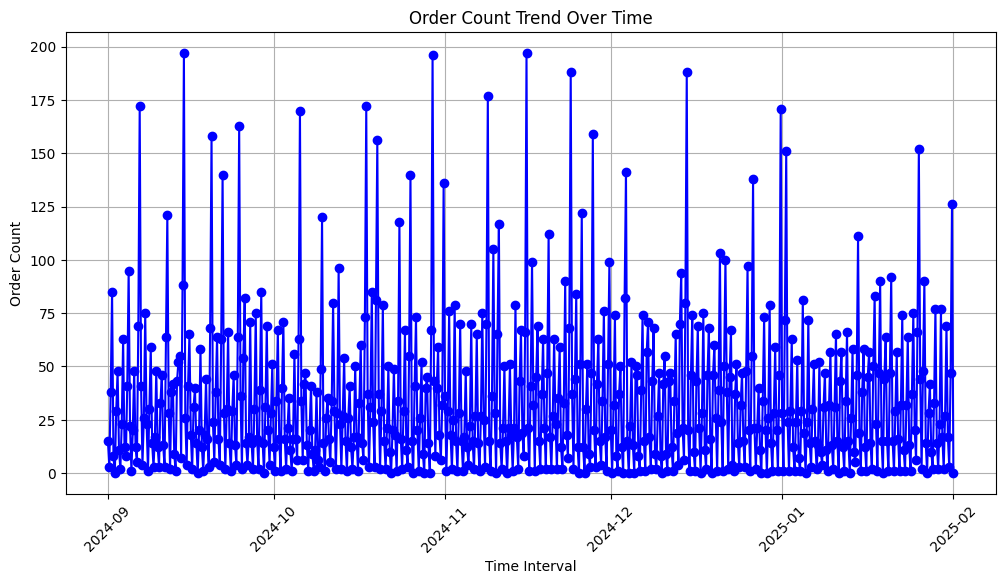

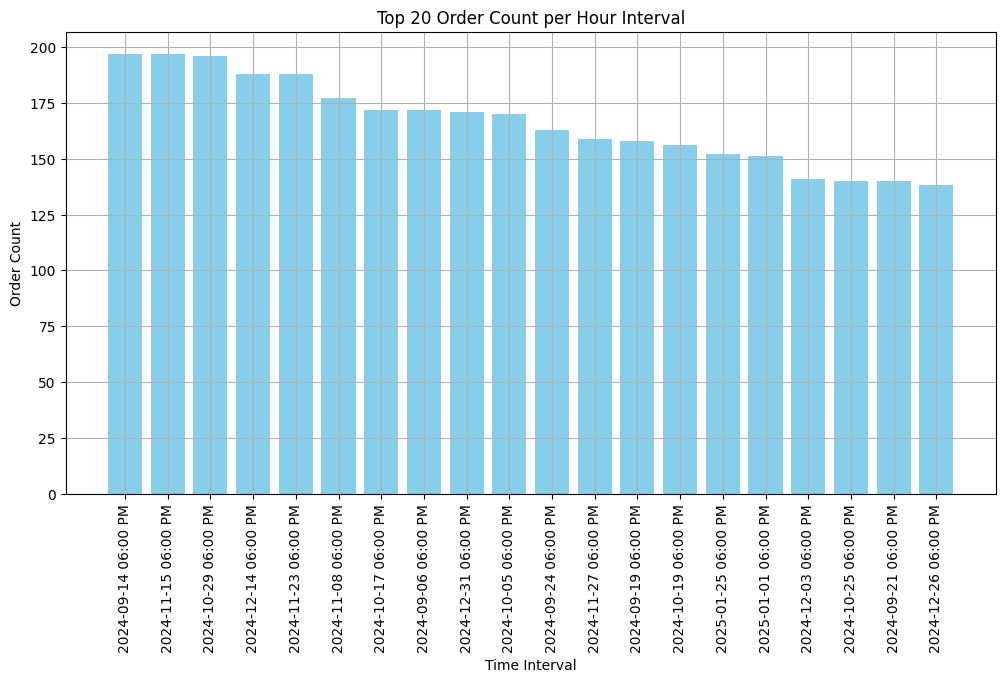

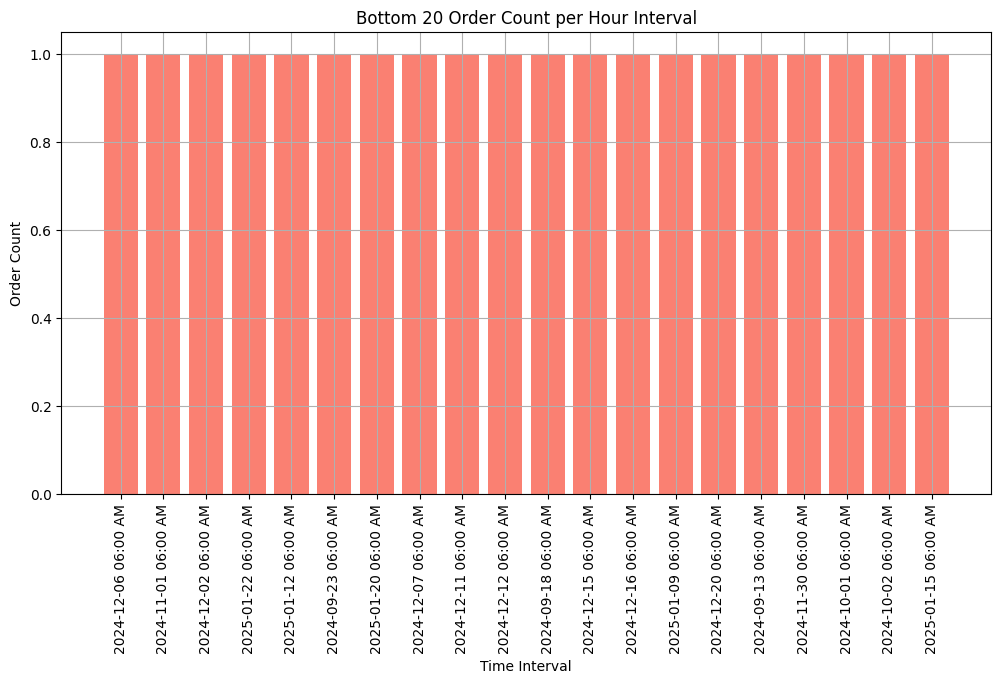


Bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):
   Order Hour Range  Order Count
2025-02-01 00:00:00            0
2024-10-22 06:00:00            0
2024-11-12 06:00:00            0
2025-01-13 06:00:00            0
2025-01-11 06:00:00            0
2024-11-25 06:00:00            0
2024-11-26 06:00:00            0
2025-01-05 06:00:00            0
2024-12-29 06:00:00            0
2025-01-19 06:00:00            0
2024-12-01 06:00:00            0
2024-12-03 06:00:00            0
2024-12-04 06:00:00            0
2024-12-05 06:00:00            0
2024-09-29 06:00:00            0
2024-12-19 06:00:00            0
2024-10-29 06:00:00            0
2024-12-17 06:00:00            0
2024-12-10 06:00:00            0
2024-12-28 06:00:00            0
2024-11-10 06:00:00            0
2024-09-17 06:00:00            0
2024-10-28 06:00:00            0
2025-01-27 06:00:00            0
2024-09-02 06:00:00            0
2024-10-26 06:00:00            0
2024-11-03 06:00:00            1

,Order Count
Order Hour Range,
2024-09-01 00:00:00,15
2024-09-01 06:00:00,3
2024-09-01 12:00:00,38
2024-09-01 18:00:00,85
2024-09-02 00:00:00,8
...,...
2024-09-24 18:00:00,163
2024-09-25 00:00:00,36
2024-09-25 06:00:00,2


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ tệp CSV và thêm cột đếm số lượng đơn hàng theo khung giờ
def process_data(file_path):
    df = pd.read_csv(file_path)
    
    # Chuyển đổi cột 'Order Placed At' thành kiểu datetime
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    
    # Tạo cột 'Order Hour Range' để nhóm theo từng khung giờ (cách nhau 6 tiếng)
    df['Order Hour Range'] = df['Order Placed At'].dt.floor('6h')  # Cách nhau 6 tiếng
    
    # Đếm số lượng đơn hàng theo từng khung giờ
    order_counts = df.groupby('Order Hour Range').size().reset_index(name='Order Count')
    
    # Tạo một dãy thời gian đầy đủ từ thời điểm sớm nhất đến muộn nhất với khung giờ 6 tiếng
    all_hours = pd.date_range(start=df['Order Placed At'].min().floor('6h'),
                              end=df['Order Placed At'].max().ceil('6h'),
                              freq='6h')
    
    # Tạo DataFrame với tất cả các khung giờ đầy đủ
    all_hours_df = pd.DataFrame(all_hours, columns=['Order Hour Range'])
    
    # Merge với bảng order_counts để điền các khung giờ không có đơn hàng (fill NaN với 0)
    full_order_counts = pd.merge(all_hours_df, order_counts, on='Order Hour Range', how='left').fillna(0)
    full_order_counts['Order Count'] = full_order_counts['Order Count'].astype(int)
    
    # Sắp xếp theo khung giờ
    full_order_counts = full_order_counts.sort_values(by='Order Hour Range')
    

    # Vẽ biểu đồ đường thể hiện số đơn hàng theo từng khung giờ theo thời gian
    plt.figure(figsize=(12, 6))
    plt.plot(full_order_counts['Order Hour Range'], full_order_counts['Order Count'], marker='o', linestyle='-', color='b')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count Trend Over Time')
    plt.xticks(rotation=45)  # Xoay trục hoành để hiển thị đầy đủ ngày và giờ
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng theo thời gian - Top 20 orders
    plt.figure(figsize=(12, 6))
    top_20_orders = order_counts.sort_values(by='Order Count', ascending=False).head(20)
    plt.bar(top_20_orders['Order Hour Range'].dt.strftime('%Y-%m-%d %I:%M %p'), top_20_orders['Order Count'], color='skyblue')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Top 20 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng ít nhất theo thời gian - Bottom 20 orders
    plt.figure(figsize=(12, 6))
    bottom_20_orders = order_counts.sort_values(by='Order Count', ascending=True).head(20)
    plt.bar(bottom_20_orders['Order Hour Range'].dt.strftime('%Y-%m-%d %I:%M %p'), bottom_20_orders['Order Count'], color='salmon')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Bottom 20 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    

    # Xuất bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (hiển thị 100 dòng đầu tiên)
    sorted_order_counts = full_order_counts.sort_values(by='Order Count', ascending=True).head(100)
    print("\nBảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):")
    print(sorted_order_counts.to_string(index=False))

    # Gán 'Order Hour Range' làm index của DataFrame
    full_order_counts = full_order_counts.set_index('Order Hour Range')
    # Đảm bảo tần suất của index là 6 giờ
    full_order_counts.index.freq = '6h'
    
    last_index = full_order_counts.index[-1]
    print("Index cuoi",last_index)
    return full_order_counts

# Đường dẫn đến tệp dữ liệu đầu vào
file_path = "cleaned_order_history.csv"
processed_df = process_data(file_path)
processed_df['Order Count'] = processed_df['Order Count'].fillna(0)
processed_df.head(100)



KIỂM TRA ĐỘ DỪNG CỦA ORDER COUNT BẰNG BIỂU ĐỒ ACF
- Các giá trị ACF dao động khá lớn ở những độ trễ đầu (lag 1-10), thậm chí có giá trị vượt ra khỏi vùng tin cậy, điều này cho thấy có thể có sự tự tương quan mạnh trong dữ liệu, dấu hiệu của một chuỗi không có tính dừng.
- Từ lag 11 trở đi, ACF nằm chủ yếu trong vùng xanh, nghĩa là sự tự tương quan dần giảm, đây là một dấu hiệu tốt hơn về tính dừng, nhưng chưa đủ để kết luận.
- Lag 36 ACF chạm 0, điều này có thể cho thấy chuỗi có xu hướng suy giảm tự tương quan theo thời gian, nhưng nếu độ trễ cần quá lớn để đạt đến trạng thái này, chuỗi vẫn có thể có đơn vị gốc.
💡 Kết luận sơ bộ: Với việc ACF vượt ra khỏi vùng tin cậy ở nhiều lag ban đầu, khả năng chuỗi có tính dừng là không chắc chắn. Tuy nhiên, vì nó giảm dần về 0 sau lag 11, có thể có tính dừng một phần. Cách tốt nhất là dùng thêm phương pháp khác để kiểm tra độ dừng, như ADF hoặc KPSS.

<Figure size 1200x600 with 0 Axes>

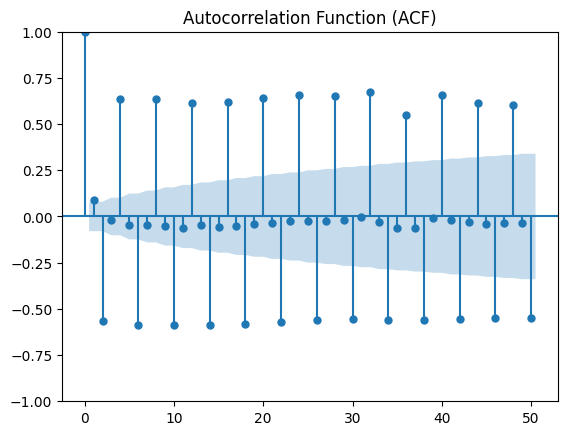

<Figure size 800x400 with 0 Axes>

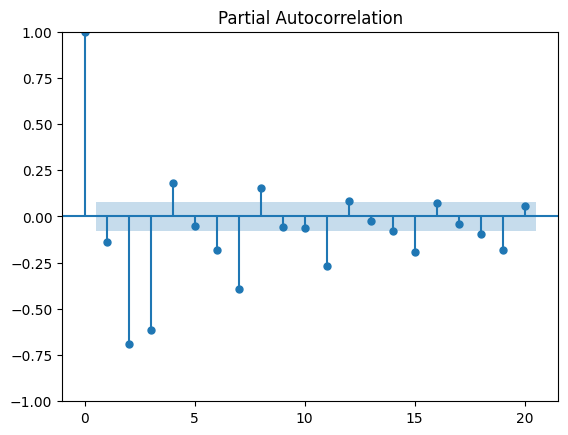

<Figure size 1200x800 with 0 Axes>

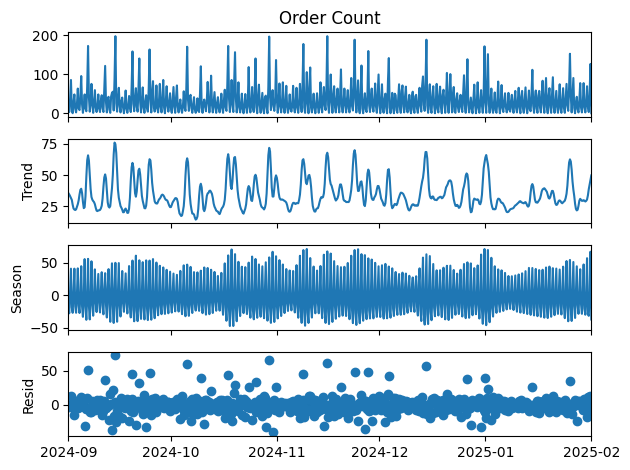

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import STL


# Kiểm tra ACF
plt.figure(figsize=(12, 6))
plot_acf(processed_df["Order Count"], lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

#Kiểm tra PACF
plt.figure(figsize=(8,4))
plot_pacf(processed_df['Order Count'].diff().dropna(), lags=20)
plt.show()

# Phân rã chuỗi thời gian bằng STL
period = 4  # Thay đổi tùy theo dữ liệu
stl = STL(processed_df["Order Count"], period=period)
result = stl.fit()

plt.figure(figsize=(12, 8))
result.plot()
plt.show()


KIỂM TRA CÁC NGÀY CÓ SỐ LƯỢNG ĐƠN HÀNG TỪ 150-200.

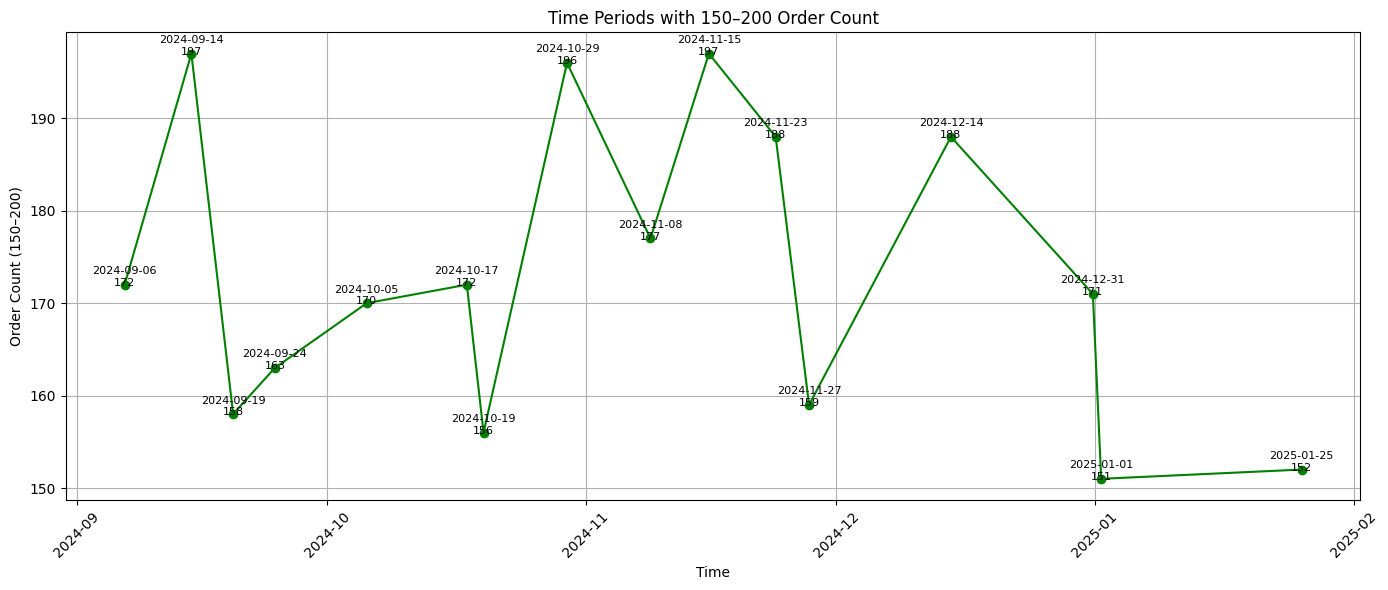

In [22]:
# Lọc những khung giờ có từ 150 đến 200 đơn hàng
filtered_df = processed_df[(processed_df['Order Count'] >= 150) & (processed_df['Order Count'] <= 200)]

# Kiểm tra xem có dữ liệu không
if not filtered_df.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(filtered_df.index, filtered_df["Order Count"], marker='o', linestyle='-', color='green')

    # Thêm ngày + số đơn hàng lên biểu đồ
    for x, y in zip(filtered_df.index, filtered_df["Order Count"]):
        label = f"{x.strftime('%Y-%m-%d')}\n{y}" if hasattr(x, 'strftime') else f"{x}\n{y}"
        plt.text(x, y + 2, label, ha='center', va='top', fontsize=8, color='black')

    plt.title("Time Periods with 150–200 Order Count")
    plt.xlabel("Time")
    plt.ylabel("Order Count (150–200)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có khung giờ nào có Order Count từ 150 đến 200.")


GIẢI THÍCH TỪNG CHỈ SỐ TRONG KẾT QUẢ
ADF Statistic = -8.2322
Đây là giá trị thống kê của kiểm định Dickey-Fuller.
-> Giá trị này càng nhỏ (âm càng lớn) thì chuỗi thời gian càng có tính dừng.

p-value = 6.02e-13 (~0.0000000000006)
Đây là xác suất để giả thuyết H₀ (chuỗi không dừng) đúng.
Vì p-value < 0.05, bác bỏ giả thuyết H₀.
->chuỗi thời gian có tính dừng.

Critical Values (Ngưỡng kiểm định)
1% mức ý nghĩa (-3.4418)
5% mức ý nghĩa (-2.8666)
10% mức ý nghĩa (-2.5694)
→ Nếu ADF Statistic nhỏ hơn một trong các giá trị này, ta bác bỏ giả thuyết H₀.

🔍 Theo kết quả, ADF Statistic (-8.2322) nhỏ hơn tất cả các mức (-3.4418, -2.8666, -2.5694), chứng tỏ chuỗi có tính dừng rất mạnh.

In [25]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller


# Kiểm định Augmented Dickey-Fuller (ADF)
def test_stationarity(series):
    result = adfuller(series.dropna())  # Loại bỏ NaN nếu có
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    
    if result[1] < 0.05:
        print("\n✅ Chuỗi thời gian có tính dừng (p-value < 0.05)")
    else:
        print("\n❌ Chuỗi thời gian không có tính dừng (p-value >= 0.05), cần lấy sai phân.")

# Kiểm tra tính dừng của cột Order Count
test_stationarity(processed_df["Order Count"])


ADF Statistic: -6.101878182372185
p-value: 9.791112896941911e-08
Critical Values:
   1%: -3.4414256033746606
   5%: -2.8664262627821473
   10%: -2.569372254520843

✅ Chuỗi thời gian có tính dừng (p-value < 0.05)


DÙNG SARIMA ĐỂ HUẤN LUYỆN MÔ HÌNH VÀ DỰ BÁO CHO FOLD 5
CHU KỲ LÀ 1 NGÀY DO ĐÓ T CHỌN m = 4 (m là số dòng trong 1 chu kỳ).
📢 Kết quả trung bình:
🔹 MSE: 451.4028
🔹 MAE: 12.2902
🔹 R²: 0.6623
🔹 R² adj: 0.6558

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=995.196, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=1050.934, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=1019.892, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=1024.827, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=1111.982, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[4] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(2,0,2)(1,0,0)[4] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(2,0,2)(2,0,1)[4] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(2,0,2)(1,0,2)[4] intercept   : AIC=988.945, Time=0.75 sec
 ARIMA(2,0,2)(0,0,2)[4] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(2,0,2)(2,0,2)[4] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(1,0,2)(1,0,2)[4] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(2,0,1)(1,0,2)[4] intercept   : AIC=969.387, Time=0.45 sec
 ARIMA(2,0,1)(0,0,2)[4] intercept   : AIC=1014.860, Time=0.27 sec
 ARIMA(2,0,1)(1,0,1)[4] intercept   : AIC=1000.892, Time=0.34 sec


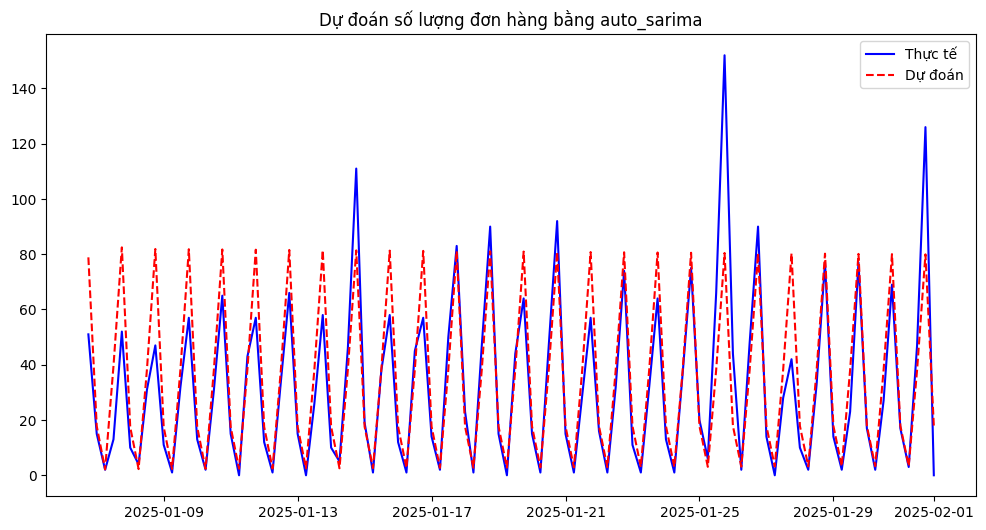

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima  # Thư viện auto_arima
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📌 Kiểm tra processed_df trước khi copy
if 'processed_df' not in locals():
    raise ValueError("processed_df chưa được định nghĩa!")

df = processed_df.copy()
df = df.dropna(subset=['Order Count'])  # ⚠️ Thêm dòng này để loại bỏ NaN


# Kiểm tra cột dữ liệu có tồn tại không
if 'Order Count' not in df.columns:
    raise KeyError("Cột 'Order Count' không tồn tại trong DataFrame!")

# Sắp xếp theo thời gian (theo index, vì 'Order Hour Range' đã là index)
df.sort_index(inplace=True)

# 🚀 5-Fold Cross Validation với TimeSeriesSplit
n_splits = 5  # 🔄 Giảm số lượng split nếu dữ liệu ít
tscv = TimeSeriesSplit(n_splits=n_splits)

mse_scores, mae_scores, r2_scores, r2_adj_scores = [], [], [], []

# 📌 Tham số ARIMA (tự động tìm tham số với auto_arima)
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train, test = df.iloc[train_idx], df.iloc[test_idx]

    if len(train) == 0 or len(test) == 0:
        print(f"⚠ Bỏ qua Fold {i+1} vì train/test rỗng!")
        continue

    # Huấn luyện mô hình với auto_arima
    try:
        # Tìm tham số tối ưu với auto_arima
        train_series = train['Order Count']
        test_series = test['Order Count']
        model = auto_arima(train_series, seasonal=True, m=4, stepwise=True, trace=True)
        # ❌ KHÔNG gọi .fit() lại nữa, vì auto_arima đã fit sẵn
        predictions = model.predict(n_periods=len(test_series))


        # Tính toán độ lỗi
        mse = mean_squared_error(test['Order Count'], predictions)
        mae = mean_absolute_error(test['Order Count'], predictions)
        r2 = r2_score(test['Order Count'], predictions)

        # Tính toán R² điều chỉnh
        n = len(test)  # Số lượng quan sát
        k = model.order[0] + model.order[1] + model.order[2]  # Số tham số trong mô hình ARIMA (p + d + q)
        r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1) if n - k - 1 > 0 else np.nan  # Tránh chia cho 0

        # Lưu kết quả
        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_scores.append(r2)
        r2_adj_scores.append(r2_adj)

        print(f"Fold {i+1} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}, R² adj: {r2_adj:.4f}")
    except Exception as e:
        print(f"⚠ Lỗi trong Fold {i+1}: {e}")
        continue

# 📊 Kết quả trung bình sau các Fold hợp lệ
if mse_scores:
    print("\n📢 Kết quả trung bình:")
    print(f"🔹 MSE: {np.mean(mse_scores):.4f}")
    print(f"🔹 MAE: {np.mean(mae_scores):.4f}")
    print(f"🔹 R²: {np.mean(r2_scores):.4f}")
    print(f"🔹 R² adj: {np.mean(r2_adj_scores):.4f}")
else:
    print("⚠ Không có Fold nào chạy thành công!")

# 📈 Vẽ đồ thị dự đoán so với thực tế (Chỉ vẽ nếu có dữ liệu)
if len(test) > 0:
    plt.figure(figsize=(12,6))
    plt.plot(test.index, test['Order Count'], label="Thực tế", color="blue")  # Sử dụng test.index (thời gian) làm trục x
    plt.plot(test.index, predictions, label="Dự đoán", linestyle="dashed", color="red")  # Sử dụng test.index (thời gian) làm trục x
    plt.legend()
    plt.title("Dự đoán số lượng đơn hàng bằng auto_sarima")
    plt.show()
else:
    print("⚠ Không có dữ liệu để vẽ biểu đồ!")


In [42]:
# Kiểm tra kiểu của index
print(type(processed_df.index))

# Kiểm tra ví dụ về giá trị trong index
print(processed_df.index[:5])  # In ra 5 giá trị đầu tiên của index

# Kiểm tra tần suất (frequency) của index
print(processed_df.index.freq)


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2024-09-01 00:00:00', '2024-09-01 06:00:00',
               '2024-09-01 12:00:00', '2024-09-01 18:00:00',
               '2024-09-02 00:00:00'],
              dtype='datetime64[ns]', name='Order Hour Range', freq='6h')
<6 * Hours>


DÙNG SARIMA ĐÃ HUẤN LUYỆN VÀ DỰ BÁO 7 NGÀY TIẾP THEO, TA THẤY DỰ BÁO KHÔNG THAY ĐỔI NHIỀU.
- ARIMA chỉ học được các mẫu tuần tự tuyến tính: ví dụ như tăng đều, giảm đều, dao động ổn định theo thời gian.
- Nếu dữ liệu không có nhiều biến động mạnh hoặc xu hướng lặp lại đều đặn, ARIMA sẽ dự báo kiểu "duy trì gần gần mức cũ".
Nói ngắn gọn: ARIMA tin rằng "những gì xảy ra gần đây sẽ lặp lại trong tương lai", nên dự báo không đa dạng nếu dữ liệu gốc phẳng hoặc chu kỳ ổn định.

👉 Số lượng đặc trưng (k): 28
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=1009.020, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=973.526, Time=0.30 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=981.270, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=1071.573, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=1009.159, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[4] intercept   : AIC=957.737, Time=0.33 sec
 ARIMA(1,0,0)(2,0,1)[4] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(1,0,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,0)(2,0,0)[4] intercept   : AIC=969.196, Time=0.28 sec
 ARIMA(2,0,0)(2,0,0)[4] intercept   : AIC=957.711, Time=0.68 sec
 ARIMA(2,0,0)(1,0,0)[4] intercept   : AIC=970.169, Time=0.28 sec
 ARIMA(2,0,0)(2,0,1)[4] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(2,0,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(3,0,0)(2,0,0)[4] intercept  

C:\Users\minhh\AppData\Local\Temp\ipykernel_23700\370847405.py:97: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=last_timestamp + pd.Timedelta(hours=6), periods=forecast_steps, freq='6H')


<Figure size 1400x600 with 0 Axes>

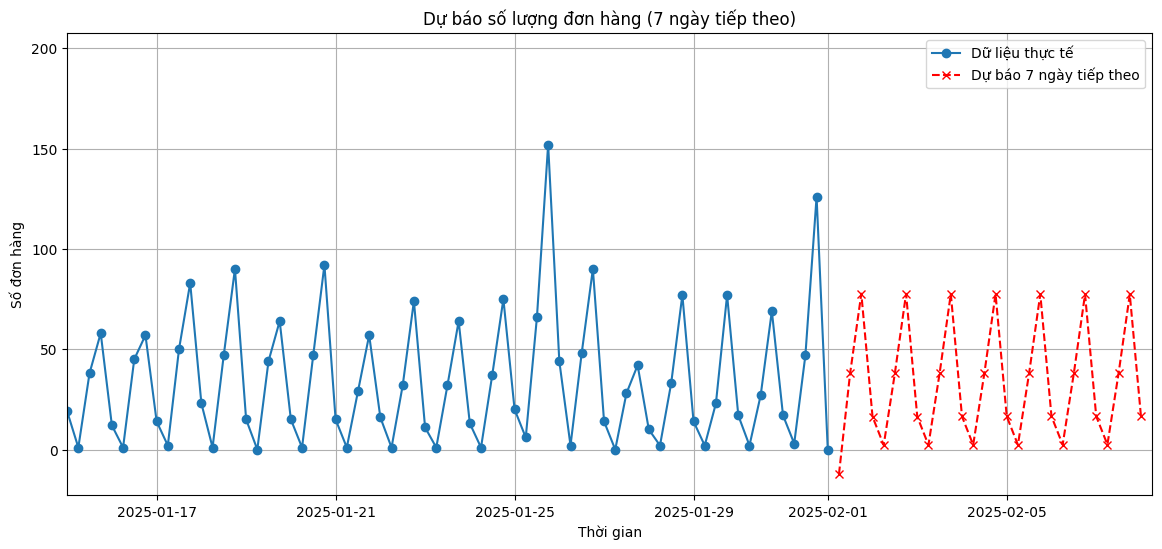

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📌 Kiểm tra processed_df
if 'processed_df' not in locals():
    raise ValueError("processed_df chưa được định nghĩa!")

df = processed_df.copy()

df = df.dropna(subset=['Order Count'])
df.sort_index(inplace=True)

if 'Order Count' not in df.columns:
    raise KeyError("Cột 'Order Count' không tồn tại trong DataFrame!")

# ======= Tạo đặc trưng lag =======
def create_lag_features(df, n_lags=4):
    df_lagged = df.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
    df_lagged = df_lagged.dropna()
    return df_lagged

# Tạo đặc trưng lag với số lượng lags = 28
n_lags = 28
df_lagged = create_lag_features(df, n_lags=n_lags)

X = df_lagged.drop(columns=['Order Count'])
y = df_lagged['Order Count']

# Kiểm tra số đặc trưng
print("👉 Số lượng đặc trưng (k):", X.shape[1])

# ======= TimeSeriesSplit (5 fold) =======
tscv = TimeSeriesSplit(n_splits=5)

# Danh sách lưu metric
mse_list, mae_list, r2_list, r2_adj_list = [], [], [], []

# Vẽ Fold cuối (fold 5)
plt.figure(figsize=(14, 6))
fold = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Huấn luyện mô hình auto_arima
    model = auto_arima(y_train, seasonal=True, m=4, stepwise=True, trace=True)
    y_pred = model.predict(n_periods=len(y_test))

    # Tính các chỉ số MSE, MAE, R2
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Tính Adjusted R²
    n = len(y_test)
    k = X_train.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    # Lưu kết quả
    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)
    r2_adj_list.append(r2_adj)

    print(f"Fold {fold} → MSE: {mse:.2f} | MAE: {mae:.2f} | R2: {r2:.2f} | R2 Adjusted: {r2_adj:.2f}")

    fold += 1

# ======= Trung bình các chỉ số =======
print("\n🔍 Trung bình các chỉ số cross-validation:")
print(f"Avg MSE        :", sum(mse_list) / len(mse_list))
print(f"Avg MAE        :", sum(mae_list) / len(mae_list))
print(f"Avg R2         :", sum(r2_list) / len(r2_list))
print(f"Avg R2 Adjusted:", sum(r2_adj_list) / len(r2_adj_list))

# ======= Huấn luyện mô hình trên toàn bộ dữ liệu =======
final_model = auto_arima(df['Order Count'], seasonal=True, m=4, stepwise=True, trace=True)

# ======= Dự báo 7 ngày tiếp theo (28 bước) =======
forecast_steps = 28
forecast = final_model.predict(n_periods=forecast_steps)

# ======= Tạo index thời gian cho dự báo =======
last_timestamp = df.index[-1]  # Thời gian cuối cùng của dữ liệu
forecast_index = pd.date_range(start=last_timestamp + pd.Timedelta(hours=6), periods=forecast_steps, freq='6H')

# ======= Gộp dự báo vào DataFrame =======
forecast_df = pd.DataFrame({'Forecast': forecast}, index=forecast_index)

# 📋 In kết quả dự báo
# print("\n🔮 Dự báo 7 ngày tiếp theo:")
# print(forecast_df)


# ======= Vẽ dự báo 7 ngày tiếp theo =======
plt.figure(figsize=(14, 6))

# Vẽ dữ liệu thực tế
plt.plot(df.index, df['Order Count'], label="Dữ liệu thực tế", marker='o')

# Vẽ phần dự báo
plt.plot(forecast_df.index, forecast_df['Forecast'], label="Dự báo 7 ngày tiếp theo", linestyle="dashed", marker='x', color='red')

# Giới hạn trục x để dễ nhìn (tùy chỉnh nếu muốn)
plt.xlim(pd.to_datetime('2025-01-15'), forecast_index[-1] + pd.Timedelta(hours=6))

# Trang trí biểu đồ
plt.legend()
plt.title("Dự báo số lượng đơn hàng (7 ngày tiếp theo)")
plt.xlabel("Thời gian")
plt.ylabel("Số đơn hàng")
plt.grid(True)
plt.show()



Dự báo bằng XGBoost, KẾT QUẢ:
Average Cross-Validation Scores:
- Avg MSE        : 226.05519395051505
- Avg MAE        : 9.173696675926152
- Avg R2         : 0.8332891464233398
- Avg R2 Adjusted: 0.8263428608576456

🧠 ĐÁNH GIÁ TỔNG QUAN
- Tổng thể, mô hình XGBoost đang hoạt động khá tốt, với R² trung bình là 0.83, nghĩa là mô hình giải thích khoảng 83% biến động của dữ liệu (có thể được cải thiện thêm, nhưng khá ổn so với dữ liệu chuỗi thời gian).
- Kết quả tốt ở fold cuối (fold 5) với R² cao 0.92 và MAE thấp 6.14, cho thấy mô hình có thể học được rất tốt trong những trường hợp dữ liệu rõ ràng hơn.
- Các fold khác có sự dao động rõ rệt trong MSE và MAE, đặc biệt là fold 2 và fold 4. Điều này có thể chỉ ra rằng mô hình gặp khó khăn khi đối mặt với một số mẫu dữ liệu, có thể là vì:
- Sự thay đổi đột ngột trong số lượng đơn hàng ở những fold đó.
- Các yếu tố không được mô hình hóa đầy đủ như: xu hướng theo tuần, theo mùa, hoặc sự kiện đặc biệt (lễ hội, khuyến mãi).

🧠 CÁCH GIẢI QUYẾT: thử so sánh các mô hình khác.

👉 Number of features used (k): 4
Fold 1 → MSE: 216.52 | MAE: 9.51 | R2: 0.82 | R2 Adjusted: 0.81
Fold 2 → MSE: 311.08 | MAE: 10.59 | R2: 0.82 | R2 Adjusted: 0.81
Fold 3 → MSE: 234.58 | MAE: 9.13 | R2: 0.82 | R2 Adjusted: 0.81
Fold 4 → MSE: 287.81 | MAE: 10.50 | R2: 0.80 | R2 Adjusted: 0.79
Fold 5 → MSE: 80.29 | MAE: 6.14 | R2: 0.92 | R2 Adjusted: 0.91

Average Cross-Validation Scores:
Avg MSE        : 226.05519395051505
Avg MAE        : 9.173696675926152
Avg R2         : 0.8332891464233398
Avg R2 Adjusted: 0.8263428608576456


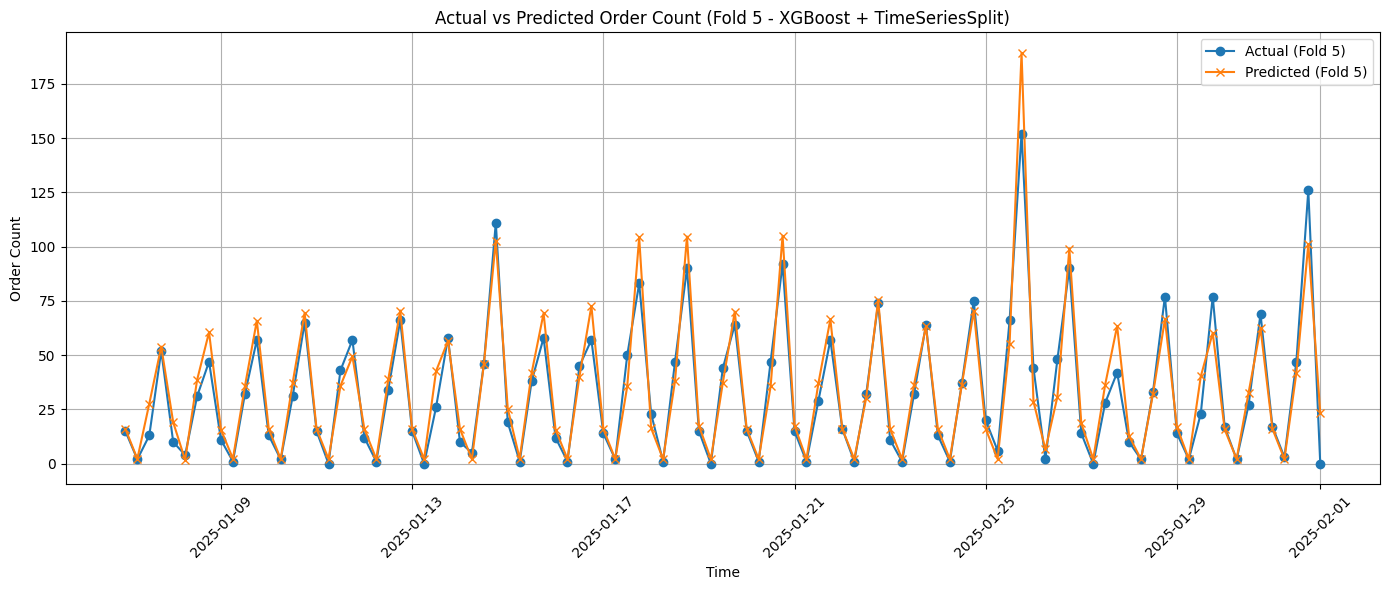

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ======= Tạo đặc trưng dạng lag =======
def create_lag_features(df, n_lags=4):
    df_lagged = df.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
    df_lagged = df_lagged.dropna()
    return df_lagged

# ======= Dữ liệu đầu vào: processed_df đã có sẵn =======
df_lagged = create_lag_features(processed_df, n_lags=4)
X = df_lagged.drop(columns=['Order Count'])
y = df_lagged['Order Count']

# Kiểm tra số đặc trưng
print("👉 Number of features used (k):", X.shape[1])

# ======= TimeSeriesSplit (5 fold) =======
tscv = TimeSeriesSplit(n_splits=5)

# Danh sách lưu metric
mse_list, mae_list, r2_list, r2_adj_list = [], [], [], []

# Vẽ Fold cuối (fold 5)
plt.figure(figsize=(14, 6))
fold = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Tính metric
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Tính Adjusted R²
    n = len(y_test)
    k = X.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    # Lưu kết quả
    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)
    r2_adj_list.append(r2_adj)

    print(f"Fold {fold} → MSE: {mse:.2f} | MAE: {mae:.2f} | R2: {r2:.2f} | R2 Adjusted: {r2_adj:.2f}")

    if fold == 5:
        plt.plot(y_test.index, y_test, label='Actual (Fold 5)', marker='o')
        plt.plot(y_test.index, y_pred, label='Predicted (Fold 5)', marker='x')

    fold += 1

# ======= Trung bình các chỉ số =======
print("\nAverage Cross-Validation Scores:")
print("Avg MSE        :", sum(mse_list) / len(mse_list))
print("Avg MAE        :", sum(mae_list) / len(mae_list))
print("Avg R2         :", sum(r2_list) / len(r2_list))
print("Avg R2 Adjusted:", sum(r2_adj_list) / len(r2_adj_list))

# ======= Biểu đồ dự đoán của Fold cuối =======
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("Actual vs Predicted Order Count (Fold 5 - XGBoost + TimeSeriesSplit)")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


NHẬN XÉT TỔNG QUAN:
- Tính chu kỳ rõ ràng:

Dự báo có dạng hình sin lặp đi lặp lại với chu kỳ khoảng 1–2 ngày.

Điều này thể hiện rằng mô hình đã học được đặc điểm tuần hoàn trong dữ liệu (có thể là theo ngày hoặc theo ca làm việc).

- Biên độ dao động giảm dần:

Từ đầu đến cuối biểu đồ, biên độ (khoảng cách giữa đỉnh và đáy) có xu hướng giảm dần.

Có thể là do đặc trưng lag làm mất dần thông tin mùa vụ xa hơn (forecast loop dần dần sử dụng giá trị dự đoán thay vì thực tế).

- Mức trung bình giảm nhẹ:

Số lượng đơn hàng trung bình có vẻ giảm theo thời gian, đặc biệt gần về cuối chuỗi dự báo.

Đây có thể là do mô hình bị suy giảm thông tin thực hoặc xu hướng trong dữ liệu gốc là đi xuống.

- Đỉnh và đáy khá cực đoan:

Một số điểm đỉnh gần 80, điểm đáy dưới 10, chứng tỏ mô hình vẫn có xu hướng dự báo mạnh.

Điều này có thể phản ánh đúng tính biến động mạnh trong thực tế, hoặc do overfitting một phần chu kỳ.

DỰ BÁO 7 NGÀY TIẾP THEO, CÓ SỰ THAY ĐỔI Ở 4 CHỈ SỐ, DO LẤY SỐ LAG = 27, LỚN HƠN TRAIN THÔNG THƯỜNG Ở TRÊN CHỈ CÓ LAG = 4.
=== KẾT QUẢ TRUNG BÌNH SAU 5 FOLD ===
🔸 MSE trung bình: 265.3057
🔸 MAE trung bình: 9.7731
🔸 R² trung bình: 0.8074
🔸 R² adjusted trung bình: 0.7320

27 97

Fold 1
🔹 MSE: 391.9638
🔹 MAE: 12.1048
🔹 R²: 0.7155
🔹 R² adjusted: 0.6042
27 97

Fold 2
🔹 MSE: 273.8452
🔹 MAE: 10.1618
🔹 R²: 0.8334
🔹 R² adjusted: 0.7683
27 97

Fold 3
🔹 MSE: 342.9447
🔹 MAE: 10.4523
🔹 R²: 0.7400
🔹 R² adjusted: 0.6382
27 97

Fold 4
🔹 MSE: 242.3013
🔹 MAE: 10.0563
🔹 R²: 0.8261
🔹 R² adjusted: 0.7580
27 97

Fold 5
🔹 MSE: 75.4736
🔹 MAE: 6.0902
🔹 R²: 0.9220
🔹 R² adjusted: 0.8915

=== KẾT QUẢ TRUNG BÌNH SAU 5 FOLD ===
🔸 MSE trung bình: 265.3057
🔸 MAE trung bình: 9.7731
🔸 R² trung bình: 0.8074
🔸 R² adjusted trung bình: 0.7320
2025-02-01 06:00:00
2025-02-07 18:00:00


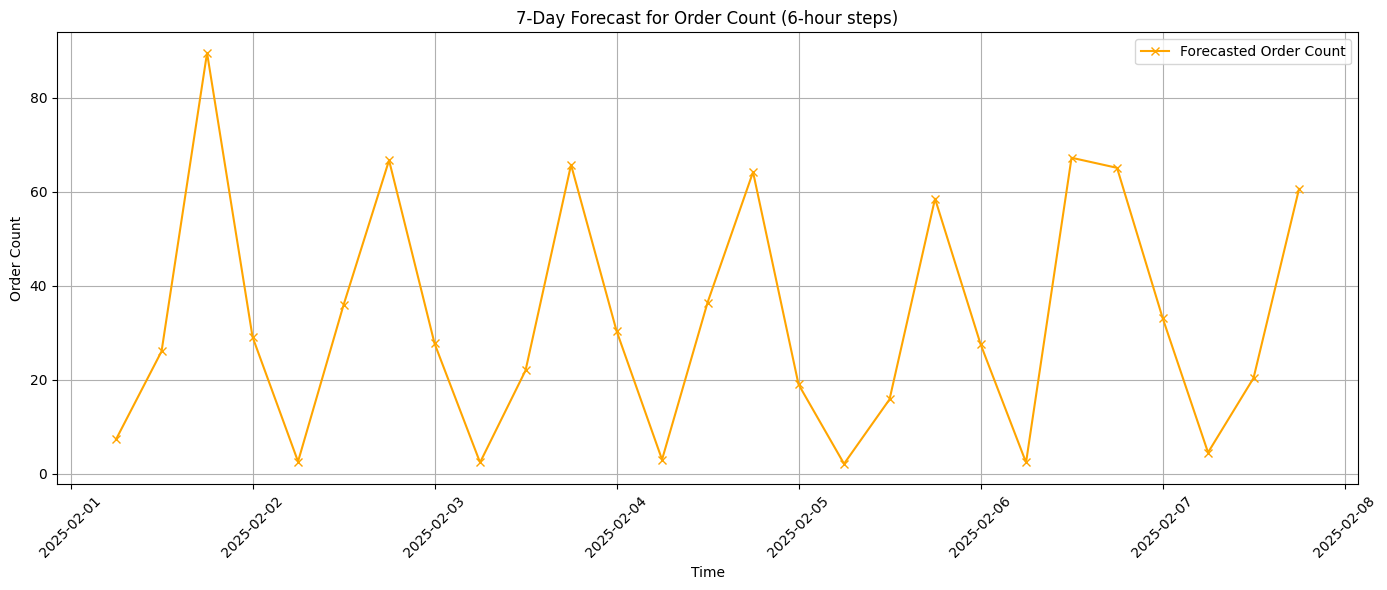

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 1. TẠO ĐẶC TRƯNG LAG ===
def create_lag_features(df, n_lags=4):
    df_lagged = df.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
    df_lagged = df_lagged.dropna()
    return df_lagged

# === 2. GIẢ SỬ processed_df ĐÃ TỒN TẠI ===
n_lags = 27  # 7 ngày = 27 giờ
df_lagged = create_lag_features(processed_df, n_lags=n_lags)

X = df_lagged.drop(columns=['Order Count'])
y = df_lagged['Order Count']

# === 3. CROSS-VALIDATION VỚI TimeSeriesSplit ===
tscv = TimeSeriesSplit(n_splits=5)

mse_scores, mae_scores, r2_scores, r2_adj_scores = [], [], [], []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred = y_pred.reshape(-1)  # Đảm bảo y_pred là 1D array (mảng một chiều)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    n = len(y_test)
    p = X_test.shape[1]
    print(p, n)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    r2_adj_scores.append(r2_adj)

    print(f"\nFold {fold+1}")
    print(f"🔹 MSE: {mse:.4f}")
    print(f"🔹 MAE: {mae:.4f}")
    print(f"🔹 R²: {r2:.4f}")
    print(f"🔹 R² adjusted: {r2_adj:.4f}")

# === 4. KẾT QUẢ TRUNG BÌNH SAU 5 FOLD ===
print("\n🔍 Trung bình các chỉ số cross-validation:")
print(f"Avg MSE        :", sum(mse_scores) / len(mse_scores))
print(f"Avg MAE        :", sum(mae_scores) / len(mae_scores))
print(f"Avg R2         :", sum(r2_scores) / len(r2_scores))
print(f"Avg R2 Adjusted:", sum(r2_adj_list) / len(r2_adj_list))

print("\n=== KẾT QUẢ TRUNG BÌNH SAU 5 FOLD ===")
print(f"🔸 MSE trung bình: {sum(mse_scores)/len(mse_scores):.4f}")
print(f"🔸 MAE trung bình: {sum(mae_scores)/len(mae_scores):.4f}")
print(f"🔸 R² trung bình: {sum(r2_scores)/len(r2_scores):.4f}")
print(f"🔸 R² adjusted trung bình: {sum(r2_adj_scores)/len(r2_adj_scores):.4f}")

# === 5. HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ĐỂ DỰ BÁO TƯƠNG LAI ===
model_final = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_final.fit(X, y)

# === 6. DỰ BÁO 7 NGÀY TIẾP THEO ===
last_window = processed_df['Order Count'].tail(n_lags).tolist()
forecast_next = []

for _ in range(27):  # 7 ngày (27 bước, mỗi bước 6 giờ)
    input_array = pd.DataFrame([last_window[-n_lags:]], columns=[f'lag_{i+1}' for i in range(n_lags)])
    y_pred = model_final.predict(input_array)[0]
    forecast_next.append(y_pred)
    last_window.append(y_pred)

# === 7. TẠO INDEX CHO DỰ BÁO TƯƠNG LAI ===
forecast_index = pd.date_range(
    start=processed_df.index[-1] + pd.Timedelta(hours=6),
    periods=27,
    freq='6h'
)

forecast_df = pd.DataFrame(forecast_next, index=forecast_index, columns=['Forecasted Order Count'])
first_index = forecast_df.index[0]
print(first_index)
last_index = forecast_df.index[-1]
print(last_index)

# === 8. VẼ BIỂU ĐỒ DỰ BÁO TƯƠNG LAI ===
plt.figure(figsize=(14, 6))
plt.plot(forecast_df.index, forecast_df['Forecasted Order Count'], label='Forecasted Order Count', color='orange', marker='x')
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("7-Day Forecast for Order Count (6-hour steps)")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



🔄 Đang chạy Fold 1...


c:\Users\minhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


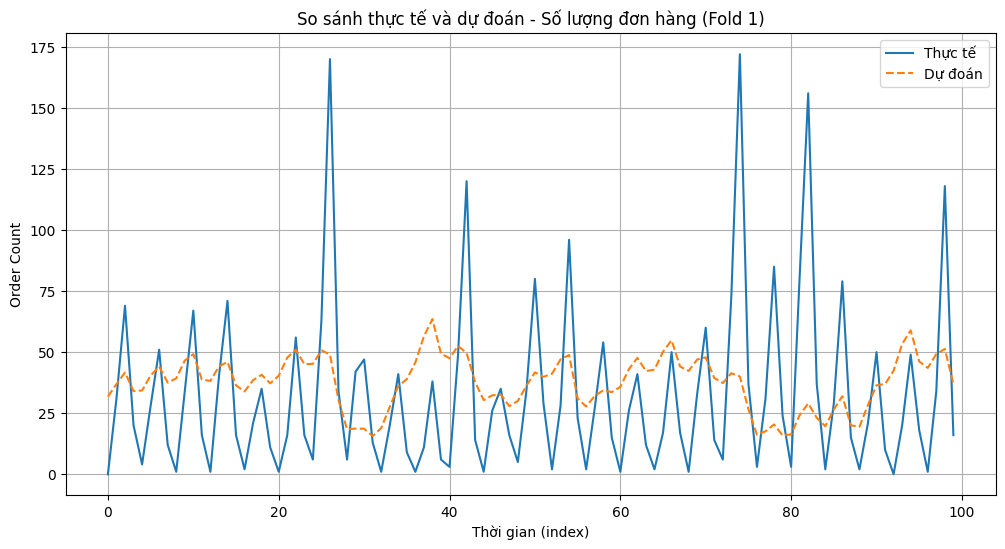


🔄 Đang chạy Fold 2...


c:\Users\minhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


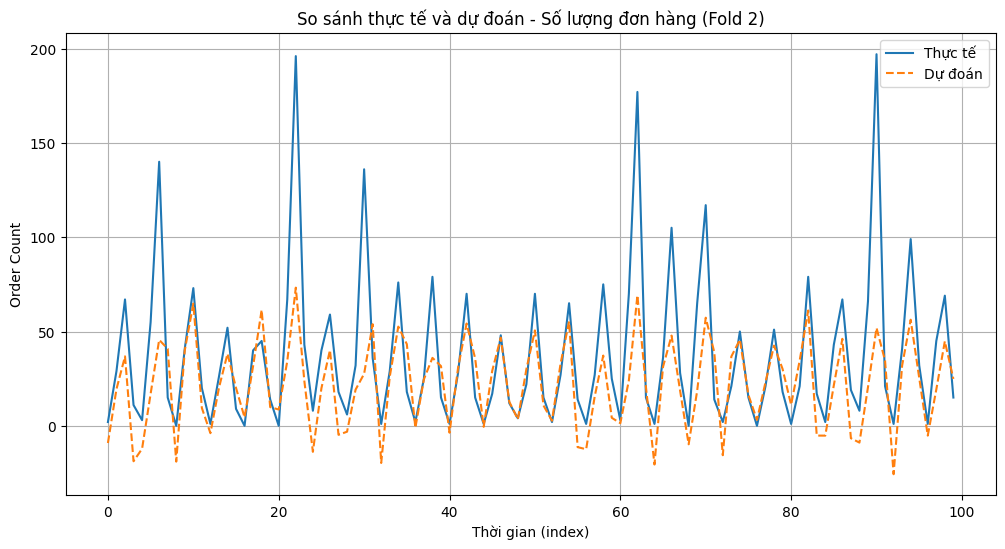


🔄 Đang chạy Fold 3...


c:\Users\minhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


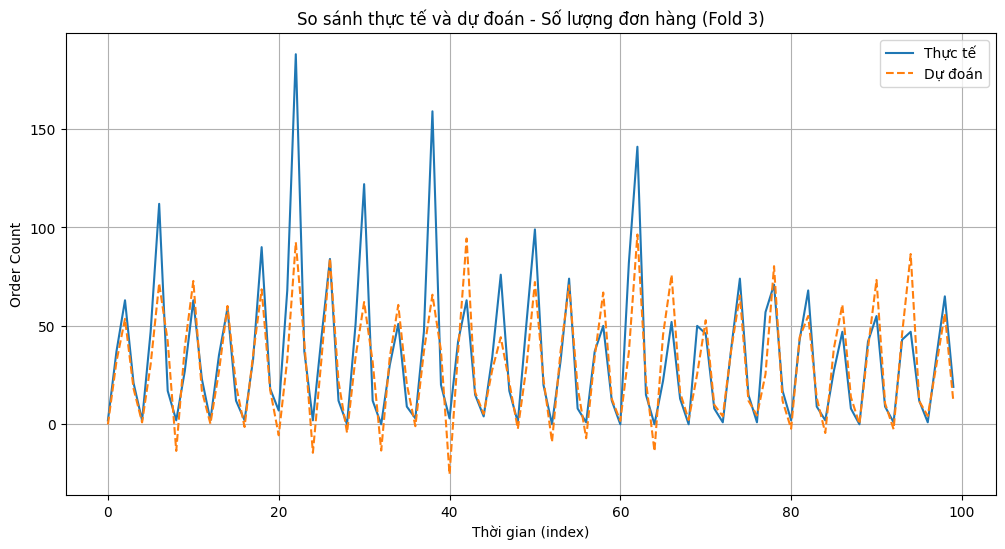


🔄 Đang chạy Fold 4...


c:\Users\minhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


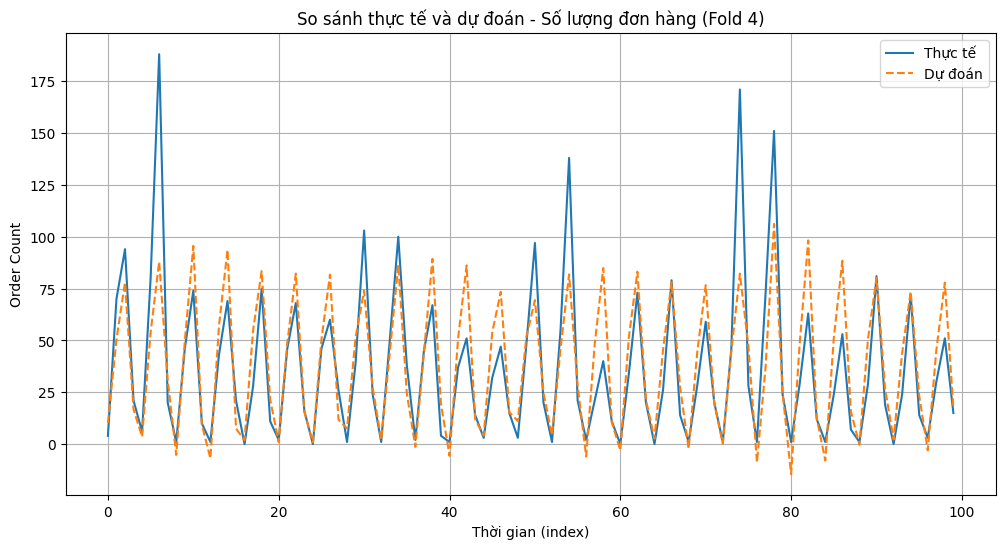


🔄 Đang chạy Fold 5...


c:\Users\minhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


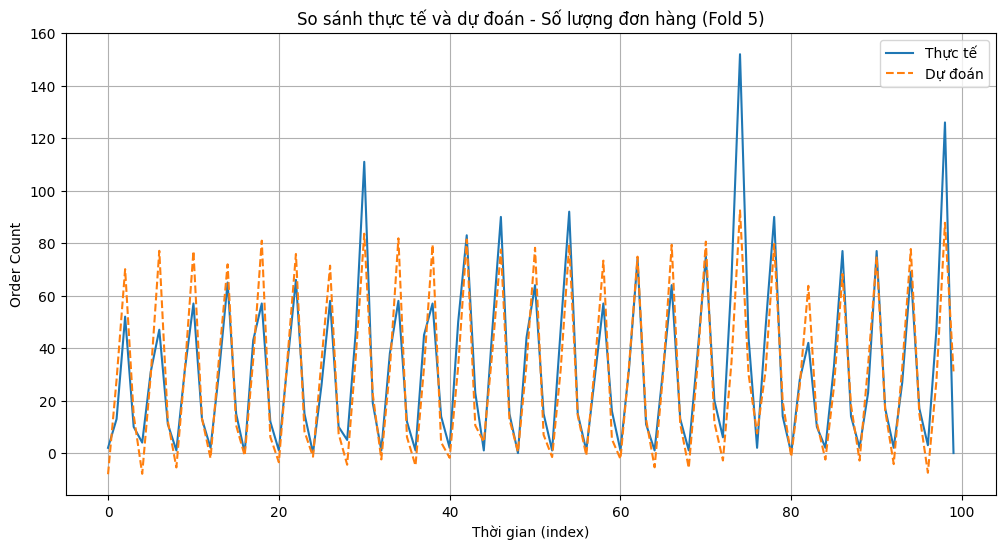


🔍 Đánh giá mô hình (sau 5-Fold Cross Validation):
✅ MSE - Trung bình: 676.25
✅ MAE - Trung bình: 16.66
✅ R² - Trung bình: 0.50
✅ R² Adjusted - Trung bình: 0.50


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import TimeSeriesSplit

# ====== BƯỚC 1: ĐỌC DỮ LIỆU ĐÃ XỬ LÝ ======
# (Giả sử bạn đã có processed_df từ hàm process_data)

# Lấy cột Order Count
data = processed_df[['Order Count']].values

# ====== BƯỚC 2: CHUẨN HÓA DỮ LIỆU ======
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# ====== BƯỚC 3: CHUẨN BỊ DỮ LIỆU CHO LSTM ======
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 12  # Dùng 12 khung giờ trước để dự đoán khung giờ tiếp theo
X, y = create_sequences(scaled_data, sequence_length)

# ====== BƯỚC 4: TIME SERIES CROSS-VALIDATION ======
tscv = TimeSeriesSplit(n_splits=5)

mse_scores = []
mae_scores = []
r2_scores = []
r2_adjusted_scores = []

# Cross-validation loop
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"\n🔄 Đang chạy Fold {fold+1}...")

    # Chia dữ liệu cho train và test
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # ====== BƯỚC 5: XÂY DỰNG MÔ HÌNH LSTM ======
    model = Sequential()
    model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # ====== BƯỚC 6: HUẤN LUYỆN MÔ HÌNH ======
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

    # ====== BƯỚC 7: DỰ ĐOÁN VÀ ĐÁNH GIÁ ======
    predicted = model.predict(X_test)
    predicted = scaler.inverse_transform(predicted)
    y_true = scaler.inverse_transform(y_test)

    # Tính toán các chỉ số
    mse = mean_squared_error(y_true, predicted)
    mae = mean_absolute_error(y_true, predicted)
    r2 = r2_score(y_true, predicted)

    # Tính R-squared adjusted
    n = len(y_test)  # Số mẫu trong test set
    p = X_train.shape[2]  # Số đặc trưng đầu vào (số units trong LSTM layer)
    r2_adjusted = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    r2_adjusted_scores.append(r2_adjusted)

    # Vẽ biểu đồ Dự đoán vs Thực tế cho mỗi fold
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='Thực tế')
    plt.plot(predicted, label='Dự đoán', linestyle='--')
    plt.title(f'So sánh thực tế và dự đoán - Số lượng đơn hàng (Fold {fold+1})')
    plt.xlabel('Thời gian (index)')
    plt.ylabel('Order Count')
    plt.legend()
    plt.grid()
    plt.show()

# ====== BƯỚC 8: IN KẾT QUẢ CROSS-VALIDATION ======
# Tính trung bình các chỉ số
mean_mse = np.mean(mse_scores)
mean_mae = np.mean(mae_scores)
mean_r2 = np.mean(r2_scores)
mean_r2_adjusted = np.mean(r2_adjusted_scores)

# In kết quả trung bình
print("\n🔍 Đánh giá mô hình (sau 5-Fold Cross Validation):")
print(f"✅ MSE - Trung bình: {mean_mse:.2f}")
print(f"✅ MAE - Trung bình: {mean_mae:.2f}")
print(f"✅ R² - Trung bình: {mean_r2:.2f}")
print(f"✅ R² Adjusted - Trung bình: {mean_r2_adjusted:.2f}")


Train shape: (557, 28, 1), Test shape: (28, 28, 1)
Epoch 1/50


c:\Users\minhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0353
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0302
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0299
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0295
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0293
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0291
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0290
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0288
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0287
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0284
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0278
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0250
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0161
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0150
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154
Epoch 16/50
35/35 ━━━━━━━━━━━━

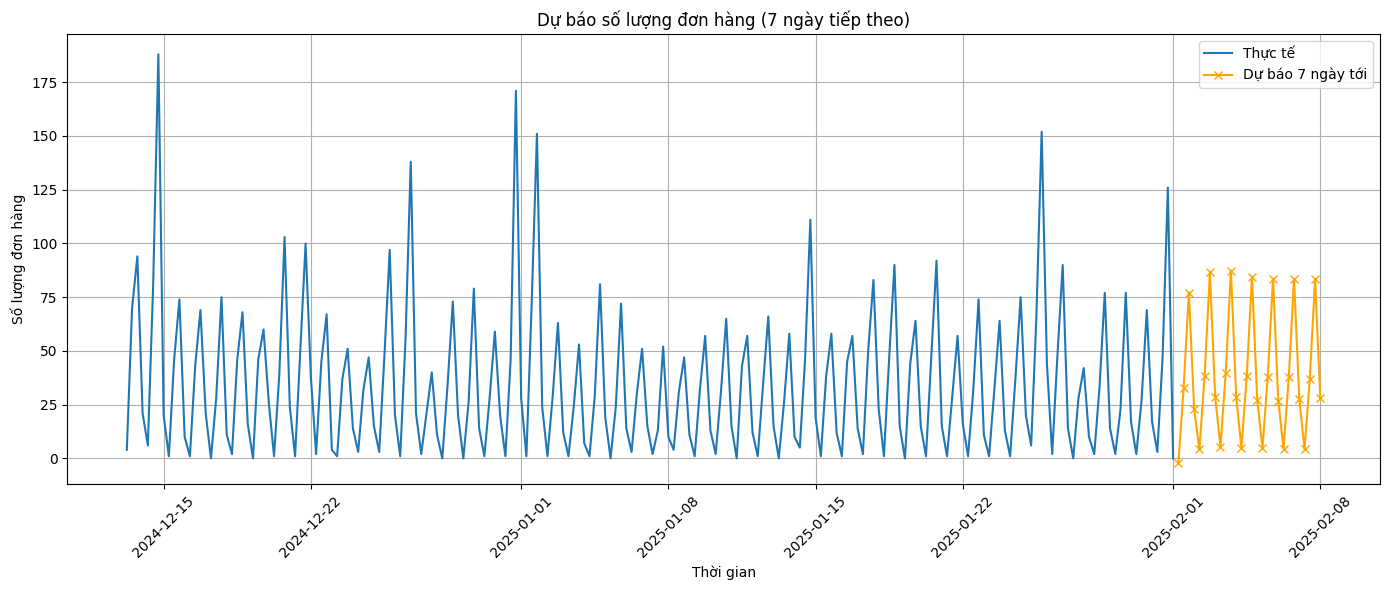

In [10]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ====== BƯỚC 1: CỐ ĐỊNH RANDOM SEED ======
# Các mô hình ở trên như SARIMA và XGBOOST không cần vì ít bị ảnh hưởng bởi ngẫu nhiên trong quá trình huấn luyện so với LSTM.
# LSTM có nhiều yếu tố ngẫu nhiên trong quá trình huấn luyện, như khởi tạo trọng số và cập nhật trọng số, vì vậy nếu bạn muốn kết quả tái lập được hoàn toàn, bạn cần phải cố định random seed.
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ====== BƯỚC 2: CHUẨN BỊ DỮ LIỆU ======
# Giả sử bạn đã có processed_df
data = processed_df[['Order Count']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# ====== BƯỚC 3: TẠO CÁC SEQUENCE ======
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 28  # 28 giờ trước để dự báo 28 giờ tiếp theo
X_all, y_all = create_sequences(scaled_data, sequence_length)

# ====== BƯỚC 4: CHIA TRAIN / TEST ======
# Train trên toàn bộ trừ 28 điểm cuối (7 ngày = 28 bước)
X_train = X_all[:-28]
y_train = y_all[:-28]

X_test = X_all[-28:]
y_test = y_all[-28:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ====== BƯỚC 5: XÂY DỰNG MÔ HÌNH LSTM ======
model = Sequential()
model.add(LSTM(64, input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# ====== BƯỚC 6: HUẤN LUYỆN ======
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# ====== BƯỚC 7: DỰ BÁO 7 NGÀY TIẾP THEO ======

# Lấy cửa sổ 28 giá trị cuối cùng
last_window = scaled_data[-sequence_length:].tolist()

forecast_scaled = []

for _ in range(28):  # Dự báo 28 bước (7 ngày)
    input_seq = np.array(last_window[-sequence_length:]).reshape(1, sequence_length, 1)
    pred = model.predict(input_seq, verbose=0)
    forecast_scaled.append(pred[0, 0])  # Lấy giá trị dự báo
    last_window.append([pred[0, 0]])  # Cập nhật cửa sổ bằng giá trị dự đoán

# Chuyển ngược dự báo về đơn vị gốc
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# Dữ liệu thực tế 7 ngày cuối
y_true = scaler.inverse_transform(y_test)

# ====== BƯỚC 8: ĐÁNH GIÁ ======
mse = mean_squared_error(y_true, forecast)
mae = mean_absolute_error(y_true, forecast)
r2 = r2_score(y_true, forecast)

# Tính Adjusted R²
n = len(y_true)  # Số mẫu (28)
p = 1            # Số lượng đặc trưng (ở đây mỗi bước chỉ dựa vào 1 chuỗi Order Count)

r2_adjusted = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n🔍 Đánh giá mô hình trên 7 ngày dự báo:")
print(f"✅ MSE: {mse:.2f}")
print(f"✅ MAE: {mae:.2f}")
print(f"✅ R²: {r2:.2f}")
print(f"✅ R² Adjusted: {r2_adjusted:.2f}")

# ====== BƯỚC 9: VẼ BIỂU ĐỒ ======
# Tạo index cho forecast
forecast_index = pd.date_range(
    start=processed_df.index[-1] + pd.Timedelta(hours=6),
    periods=28,
    freq='6h'
)

plt.figure(figsize=(14, 6))
plt.plot(processed_df.index[-200:], processed_df['Order Count'][-200:], label='Thực tế')
plt.plot(forecast_index, forecast, label='Dự báo 7 ngày tới', color='orange', marker='x')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng đơn hàng')
plt.title('Dự báo số lượng đơn hàng (7 ngày tiếp theo)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
print(df_lagged.tail(10))  # Kiểm tra 10 dòng cuối cùng của df_lagged


                     Order Count  lag_1  lag_2  lag_3  lag_4
Order Hour Range                                            
2025-01-29 18:00:00           77   23.0    2.0   14.0   77.0
2025-01-30 00:00:00           17   77.0   23.0    2.0   14.0
2025-01-30 06:00:00            2   17.0   77.0   23.0    2.0
2025-01-30 12:00:00           27    2.0   17.0   77.0   23.0
2025-01-30 18:00:00           69   27.0    2.0   17.0   77.0
2025-01-31 00:00:00           17   69.0   27.0    2.0   17.0
2025-01-31 06:00:00            3   17.0   69.0   27.0    2.0
2025-01-31 12:00:00           47    3.0   17.0   69.0   27.0
2025-01-31 18:00:00          126   47.0    3.0   17.0   69.0
2025-02-01 00:00:00            0  126.0   47.0    3.0   17.0
